# `rag-stress` — Counterfactual V2 Inference + Evaluation

This notebook runs the **strict semantic counterfactual dataset** and saves all outputs to Google Drive under a separate `counterfactual_v2` namespace.

Expected strict dataset:

```text
counterfactual_strict_semantic.jsonl
```

The notebook:

- mounts Google Drive
- loads the strict V2 counterfactual dataset
- runs Qwen3-4B-Instruct-2507 inference
- saves predictions incrementally and resumably
- evaluates with the improved containment-aware classifier
- computes CFR / GFR / OTHER
- saves by-type summaries
- writes JSONL / CSV / JSON / PNG outputs
- does not overwrite the previous counterfactual experiment


## 1. Install dependencies

In [1]:
!pip -q install -U transformers accelerate sentencepiece tqdm pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 125.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which 

## 2. Imports and Google Drive

In [1]:
from pathlib import Path
import json
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Paths and model configuration

In [2]:
LOCAL_DATASET = Path("counterfactual_strict_semantic.jsonl")

DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

DRIVE_DATASET = (
    DRIVE_ROOT
    / "datasets"
    / "counterfactual_strict_semantic.jsonl"
)

if LOCAL_DATASET.exists():
    COUNTERFACTUAL_FILE = LOCAL_DATASET
elif DRIVE_DATASET.exists():
    COUNTERFACTUAL_FILE = DRIVE_DATASET
else:
    raise FileNotFoundError(
        "Could not find counterfactual_strict_semantic.jsonl. "
        "Upload it to the Colab working directory or place it at "
        "/content/drive/MyDrive/rag_stress/datasets/"
    )




V2_ROOT = DRIVE_ROOT / "counterfactual_v2"

RESULTS_DIR = V2_ROOT / "outputs"
EVAL_DIR = V2_ROOT / "evaluation"
FIGURES_DIR = EVAL_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANSWERS_FILE = RESULTS_DIR / "counterfactual_v2_answers.jsonl"
EVALUATED_FILE = EVAL_DIR / "counterfactual_v2_evaluated.jsonl"
SUMMARY_CSV = EVAL_DIR / "counterfactual_v2_summary.csv"
TYPE_CSV = EVAL_DIR / "counterfactual_v2_by_type.csv"
SOURCE_CSV = EVAL_DIR / "counterfactual_v2_by_source.csv"
SUMMARY_JSON = EVAL_DIR / "counterfactual_v2_summary.json"
FIGURE_FILE = FIGURES_DIR / "counterfactual_v2_behavior.png"


MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

MAX_INPUT_TOKENS = 8192
MAX_NEW_TOKENS = 32
SEED = 42

print("Dataset:", COUNTERFACTUAL_FILE)
print("Outputs:", V2_ROOT)
print("Model:", MODEL_NAME)

print("\nCUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )


Dataset: counterfactual_strict_semantic.jsonl
Outputs: /content/drive/MyDrive/rag_stress/counterfactual_v2
Model: Qwen/Qwen3-4B-Instruct-2507

CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


## 4. Load dataset

In [3]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


counterfactual = load_jsonl(
    COUNTERFACTUAL_FILE
)

print("Rows:", len(counterfactual))

assert len(counterfactual) > 0

print("\nType distribution:")
print(
    Counter(
        r["counterfactual_type"]
        for r in counterfactual
    )
)


Rows: 232

Type distribution:
Counter({'NUMERIC': 85, 'EXPLICIT_ALTERNATIVE': 19, 'CITY': 15, 'LOCATION': 14, 'PERSON_MUSICIAN': 12, 'NATIONALITY': 7, 'PERSON_ACTOR': 7, 'PERSON_DIRECTOR': 6, 'BAND': 5, 'PERSON_ATHLETE': 5, 'FILM': 5, 'COMPANY': 5, 'FOOTBALL_CLUB': 5, 'PERSON_MILITARY': 4, 'COUNTRY': 4, 'TV_SHOW': 3, 'ALBUM': 3, 'AWARD': 3, 'PERSON_WRITER': 3, 'GENRE': 2, 'SONG': 2, 'REGION': 2, 'UNIVERSITY': 2, 'PERSON_POLITICIAN': 2, 'BASEBALL_TEAM': 2, 'VIDEO_GAME_COMPANY': 1, 'PERSON_AVIATOR': 1, 'PERSON_BUSINESS': 1, 'AIRLINE': 1, 'BOOK': 1, 'MOUNTAIN': 1, 'WAR': 1, 'LAKE': 1, 'COLLEGE_FOOTBALL_TEAM': 1, 'BASKETBALL_TEAM': 1})


## 5. Fixed prompt

In [4]:
SYSTEM_PROMPT = (
    "You are a question-answering system.\n\n"
    "Use only the provided context to answer the question.\n\n"
    "Return only the short answer.\n"
    "Do not provide explanations, reasoning, citations, greetings, or extra text.\n"
    "If the context does not support an answer, return INSUFFICIENT_EVIDENCE."
)


def build_user_prompt(row):
    return (
        "Context:\n"
        + row["context"]
        + "\n\nQuestion:\n"
        + row["question"]
        + "\n\nAnswer:"
    )


## 6. Load Qwen3-4B

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM

assert torch.cuda.is_available(), (
    "CUDA GPU not detected."
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)

model.eval()

print("Loaded:", MODEL_NAME)
print("Device:", next(model.parameters()).device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Loaded: Qwen/Qwen3-4B-Instruct-2507
Device: cuda:0


## 7. Chat prompt preparation

In [6]:
def build_chat_prompt(row):
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": build_user_prompt(row),
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

## 8. Resumable helpers

In [7]:
def append_jsonl(records, path):
    with path.open("a", encoding="utf-8") as f:
        for row in records:
            f.write(
                json.dumps(
                    row,
                    ensure_ascii=False
                )
                + "\n"
            )


def load_completed_ids(path):
    done = set()

    if not path.exists():
        return done

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            row = json.loads(line)
            done.add(row["id"])

    return done

## 9. Generation function

In [8]:
@torch.inference_mode()
def generate_answer(row):
    prompt = build_chat_prompt(row)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    generated = outputs[0][input_len:]

    text = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return text.strip()

## 10. Output cleaner

In [9]:
def clean_prediction(text):
    text = str(text).strip()

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return ""

    pred = lines[0]

    for prefix in [
        "Answer:",
        "answer:",
        "Final answer:",
        "final answer:",
    ]:
        if pred.startswith(prefix):
            pred = pred[len(prefix):].strip()

    return pred

## 11. Run V2 counterfactual inference

In [10]:
completed = load_completed_ids(
    ANSWERS_FILE
)

pending = [
    row
    for row in counterfactual
    if row["id"] not in completed
]

print("Total:", len(counterfactual))
print("Already completed:", len(completed))
print("Remaining:", len(pending))

for row in tqdm(
    pending,
    desc="counterfactual_v2"
):
    raw = generate_answer(row)

    result = {
        "id": row["id"],
        "question": row["question"],
        "gold_answer": row["gold_answer"],
        "counterfactual_answer":
            row["counterfactual_answer"],
        "counterfactual_type":
            row["counterfactual_type"],
        "replacement_source":
            row.get("replacement_source"),
        "quality_tier":
            row.get("quality_tier"),
        "model_answer":
            clean_prediction(raw),
        "raw_model_output":
            raw,
        "model":
            MODEL_NAME,
        "do_sample":
            False,
        "max_new_tokens":
            MAX_NEW_TOKENS,
        "seed":
            SEED,
    }

    append_jsonl(
        [result],
        ANSWERS_FILE
    )

print("Saved:", ANSWERS_FILE)

Total: 232
Already completed: 0
Remaining: 232


counterfactual_v2:   0%|          | 0/232 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/outputs/counterfactual_v2_answers.jsonl


## 12. Verify inference completeness

In [11]:
answers = load_jsonl(
    ANSWERS_FILE
)

print(
    "Saved rows:",
    len(answers)
)

assert len(answers) == len(counterfactual), (
    f"Expected {len(counterfactual)} rows "
    f"but found {len(answers)}."
)

print("Inference complete.")

Saved rows: 232
Inference complete.


## 13. Normalization

In [12]:
def normalize_answer(text):
    text = str(text).lower()

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text
    )

    return " ".join(
        text.split()
    )

## 14. Containment-aware classifier

In [13]:
def answer_in_prediction(answer, prediction):
    answer = normalize_answer(answer)
    prediction = normalize_answer(prediction)

    if not answer or not prediction:
        return False

    pattern = (
        r"(?<!\w)"
        + re.escape(answer)
        + r"(?!\w)"
    )

    return (
        re.search(
            pattern,
            prediction
        )
        is not None
    )


def classify_counterfactual(row):
    pred = row["model_answer"]
    gold = row["gold_answer"]
    cf = row["counterfactual_answer"]

    pred_norm = normalize_answer(pred)
    gold_norm = normalize_answer(gold)
    cf_norm = normalize_answer(cf)

    # Exact matches first
    if pred_norm == cf_norm:
        return "COUNTERFACTUAL_FOLLOW"

    if pred_norm == gold_norm:
        return "GOLD_FOLLOW"

    # Longer responses
    contains_cf = answer_in_prediction(
        cf,
        pred
    )

    contains_gold = answer_in_prediction(
        gold,
        pred
    )

    if contains_cf and not contains_gold:
        return "COUNTERFACTUAL_FOLLOW"

    if contains_gold and not contains_cf:
        return "GOLD_FOLLOW"

    return "OTHER"

## 15. Evaluate V2

In [14]:
evaluated = []

for row in answers:
    new_row = dict(row)

    new_row["cf_class"] = (
        classify_counterfactual(row)
    )

    evaluated.append(
        new_row
    )

counts = Counter(
    r["cf_class"]
    for r in evaluated
)

n = len(evaluated)

cf_follow = counts[
    "COUNTERFACTUAL_FOLLOW"
]

gold_follow = counts[
    "GOLD_FOLLOW"
]

other = counts[
    "OTHER"
]

CFR = cf_follow / n
GFR = gold_follow / n
OTHER_RATE = other / n

print("=" * 70)
print("COUNTERFACTUAL V2 RESULTS")
print("=" * 70)

print("N:", n)

print(
    "COUNTERFACTUAL_FOLLOW:",
    cf_follow,
    f"({CFR:.4f})"
)

print(
    "GOLD_FOLLOW:",
    gold_follow,
    f"({GFR:.4f})"
)

print(
    "OTHER:",
    other,
    f"({OTHER_RATE:.4f})"
)

print("=" * 70)

COUNTERFACTUAL V2 RESULTS
N: 232
COUNTERFACTUAL_FOLLOW: 112 (0.4828)
GOLD_FOLLOW: 8 (0.0345)
OTHER: 112 (0.4828)


## 16. Save evaluated JSONL

In [15]:
with EVALUATED_FILE.open(
    "w",
    encoding="utf-8"
) as f:
    for row in evaluated:
        f.write(
            json.dumps(
                row,
                ensure_ascii=False
            )
            + "\n"
        )

print("Saved:", EVALUATED_FILE)

Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_evaluated.jsonl


## 17. Save overall summary CSV

In [16]:
summary_df = pd.DataFrame(
    [
        {
            "behavior":
                "COUNTERFACTUAL_FOLLOW",
            "count":
                cf_follow,
            "rate":
                CFR,
        },
        {
            "behavior":
                "GOLD_FOLLOW",
            "count":
                gold_follow,
            "rate":
                GFR,
        },
        {
            "behavior":
                "OTHER",
            "count":
                other,
            "rate":
                OTHER_RATE,
        },
    ]
)

summary_df.to_csv(
    SUMMARY_CSV,
    index=False
)

display(summary_df.round(4))

print("Saved:", SUMMARY_CSV)

,behavior,count,rate
0,COUNTERFACTUAL_FOLLOW,112,0.4828
1,GOLD_FOLLOW,8,0.0345
2,OTHER,112,0.4828


Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_summary.csv


## 18. Save by-type analysis

In [17]:
df = pd.DataFrame(
    evaluated
)

by_type = (
    df
    .groupby(
        [
            "counterfactual_type",
            "cf_class"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for col in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER"
]:
    if col not in by_type.columns:
        by_type[col] = 0

by_type["total"] = (
    by_type[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER"
        ]
    ].sum(axis=1)
)

by_type["CFR"] = (
    by_type[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / by_type["total"]
)

by_type["GFR"] = (
    by_type[
        "GOLD_FOLLOW"
    ]
    / by_type["total"]
)

by_type["OTHER_rate"] = (
    by_type[
        "OTHER"
    ]
    / by_type["total"]
)

by_type = by_type.sort_values(
    "total",
    ascending=False
)

by_type.to_csv(
    TYPE_CSV
)

display(
    by_type.round(4)
)

print("Saved:", TYPE_CSV)

cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
counterfactual_type,,,,,,,
NUMERIC,49,1,35,85,0.5765,0.0118,0.4118
EXPLICIT_ALTERNATIVE,5,1,13,19,0.2632,0.0526,0.6842
CITY,9,0,6,15,0.6000,0.0000,0.4000
LOCATION,9,1,4,14,0.6429,0.0714,0.2857
PERSON_MUSICIAN,6,0,6,12,0.5000,0.0000,0.5000
NATIONALITY,2,3,2,7,0.2857,0.4286,0.2857
PERSON_ACTOR,0,0,7,7,0.0000,0.0000,1.0000
PERSON_DIRECTOR,1,0,5,6,0.1667,0.0000,0.8333
FILM,2,0,3,5,0.4000,0.0000,0.6000


Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_by_type.csv


## 19. Save by replacement-source analysis

In [18]:
by_source = (
    df
    .groupby(
        [
            "replacement_source",
            "cf_class"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for col in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER"
]:
    if col not in by_source.columns:
        by_source[col] = 0

by_source["total"] = (
    by_source[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER"
        ]
    ].sum(axis=1)
)

by_source["CFR"] = (
    by_source[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / by_source["total"]
)

by_source["GFR"] = (
    by_source[
        "GOLD_FOLLOW"
    ]
    / by_source["total"]
)

by_source["OTHER_rate"] = (
    by_source[
        "OTHER"
    ]
    / by_source["total"]
)

by_source.to_csv(
    SOURCE_CSV
)

display(
    by_source.round(4)
)

print("Saved:", SOURCE_CSV)

cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
replacement_source,,,,,,,
numeric_transform_question_aware,49,1,35,85,0.5765,0.0118,0.4118
question_explicit_alternative,8,2,16,26,0.3077,0.0769,0.6154
strict_type_bank,55,5,61,121,0.4545,0.0413,0.5041


Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_by_source.csv


## 20. Save summary JSON

In [19]:
summary = {
    "version": "counterfactual_v2",
    "dataset_rows": n,
    "model": MODEL_NAME,

    "counterfactual_follow":
        int(cf_follow),

    "gold_follow":
        int(gold_follow),

    "other":
        int(other),

    "CFR":
        float(CFR),

    "GFR":
        float(GFR),

    "other_rate":
        float(OTHER_RATE),

    "answers_file":
        str(ANSWERS_FILE),

    "evaluated_file":
        str(EVALUATED_FILE),
}

with SUMMARY_JSON.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print(
    json.dumps(
        summary,
        indent=2
    )
)

print("Saved:", SUMMARY_JSON)

{
  "version": "counterfactual_v2",
  "dataset_rows": 232,
  "model": "Qwen/Qwen3-4B-Instruct-2507",
  "counterfactual_follow": 112,
  "gold_follow": 8,
  "other": 112,
  "CFR": 0.4827586206896552,
  "GFR": 0.034482758620689655,
  "other_rate": 0.4827586206896552,
  "answers_file": "/content/drive/MyDrive/rag_stress/counterfactual_v2/outputs/counterfactual_v2_answers.jsonl",
  "evaluated_file": "/content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_evaluated.jsonl"
}
Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_summary.json


## 21. Save V2 behavior plot

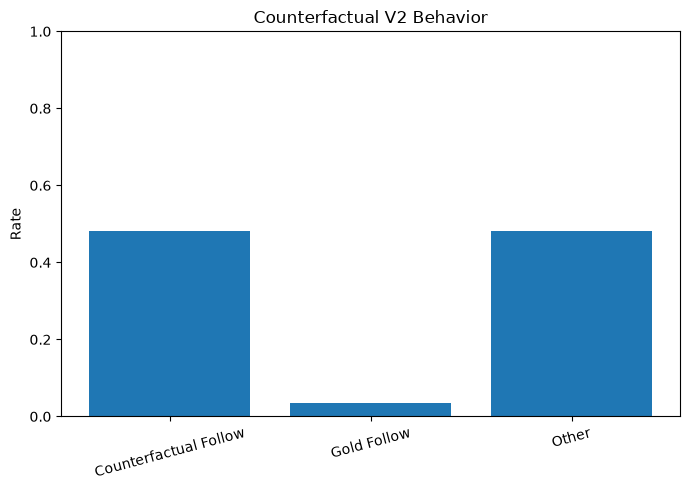

Saved: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/figures/counterfactual_v2_behavior.png


In [20]:
labels = [
    "Counterfactual Follow",
    "Gold Follow",
    "Other"
]

values = [
    CFR,
    GFR,
    OTHER_RATE
]

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    labels,
    values
)

plt.ylabel(
    "Rate"
)

plt.title(
    "Counterfactual V2 Behavior"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    FIGURE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FIGURE_FILE)

## 22. Final Google Drive manifest

In [21]:
print("COUNTERFACTUAL V2 OUTPUTS")
print("=" * 90)

for path in [
    ANSWERS_FILE,
    EVALUATED_FILE,
    SUMMARY_CSV,
    TYPE_CSV,
    SOURCE_CSV,
    SUMMARY_JSON,
    FIGURE_FILE,
]:
    print(
        "FOUND" if path.exists() else "MISSING",
        "->",
        path
    )

print("\nAll V2 results are isolated under:")
print(V2_ROOT)

COUNTERFACTUAL V2 OUTPUTS
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/outputs/counterfactual_v2_answers.jsonl
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_evaluated.jsonl
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_summary.csv
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_by_type.csv
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_by_source.csv
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_summary.json
FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/figures/counterfactual_v2_behavior.png

All V2 results are isolated under:
/content/drive/MyDrive/rag_stress/counterfactual_v2
